In [1]:
import sys
from pathlib import Path

import numpy as np
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from baselines.baseline_center_fan import repair_one_sample_center_fan
from baselines.baseline_planar_triangulation import repair_one_sample_planar
from baselines.baseline_planar_largest_hole import repair_one_sample_planar_largest_hole

In [3]:
dataset_root = project_root / "dataset"
vis_root = project_root / "results" / "vis"
vis_root.mkdir(parents=True, exist_ok=True)

sample_ids = ["42103", "35580", "37784"]

print("dataset_root:", dataset_root)
print("vis_root:", vis_root)
print("sample_ids:", sample_ids)

dataset_root: D:\MyJupyter\Works\3Dsegment\dataset
vis_root: D:\MyJupyter\Works\3Dsegment\results\vis
sample_ids: ['42103', '35580', '37784']


In [4]:
def clone_mesh(mesh):
    mesh_copy = o3d.geometry.TriangleMesh()
    mesh_copy.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices).copy())
    mesh_copy.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.triangles).copy())
    if mesh.has_vertex_normals():
        mesh_copy.vertex_normals = o3d.utility.Vector3dVector(np.asarray(mesh.vertex_normals).copy())
    if mesh.has_triangle_normals():
        mesh_copy.triangle_normals = o3d.utility.Vector3dVector(np.asarray(mesh.triangle_normals).copy())
    return mesh_copy


def prepare_mesh_for_vis(mesh, color=None):
    mesh_vis = clone_mesh(mesh)
    if color is not None:
        mesh_vis.paint_uniform_color(color)
    mesh_vis.compute_triangle_normals()
    mesh_vis.compute_vertex_normals()
    return mesh_vis

In [5]:
def get_camera_from_mesh(mesh, scale=1.8):
    bbox = mesh.get_axis_aligned_bounding_box()
    center = bbox.get_center()
    extent = bbox.get_extent()
    radius = max(float(np.linalg.norm(extent)), 1e-6)

    lookat = center
    front = np.array([0.35, -0.45, -0.82], dtype=np.float64)
    front = front / np.linalg.norm(front)
    up = np.array([0.0, 1.0, 0.0], dtype=np.float64)
    zoom = 0.7

    return {
        "lookat": lookat,
        "front": front,
        "up": up,
        "zoom": zoom,
        "radius": radius * scale,
    }

In [6]:
def save_mesh_image(mesh, out_path, width=900, height=900, color=None):
    mesh_vis = prepare_mesh_for_vis(mesh, color=color)
    cam = get_camera_from_mesh(mesh_vis)

    vis = o3d.visualization.Visualizer()
    vis.create_window(width=width, height=height, visible=True)
    vis.add_geometry(mesh_vis)

    render_opt = vis.get_render_option()
    render_opt.mesh_show_back_face = True
    render_opt.light_on = True

    ctr = vis.get_view_control()
    ctr.set_lookat(cam["lookat"])
    ctr.set_front(cam["front"])
    ctr.set_up(cam["up"])
    ctr.set_zoom(cam["zoom"])

    vis.poll_events()
    vis.update_renderer()
    vis.capture_screen_image(str(out_path), do_render=True)
    vis.destroy_window()

In [7]:
def summarize_result(out):
    return {
        "sample_id": out["sample_id"],
        "success": out["success"],
        "reason": out.get("reason"),
        "num_loops_repaired": out.get("num_loops_repaired"),
        "total_loop_len_before": out.get("total_loop_len_before"),
        "nearest_loop_len_after": out.get("nearest_loop_len_after"),
        "improvement": out.get("improvement"),
        "num_new_vertices": out.get("num_new_vertices"),
        "num_added_faces": out.get("num_added_faces"),
        "mean_added_face_quality": out.get("mean_added_face_quality"),
        "min_added_face_quality": out.get("min_added_face_quality"),
        "num_added_faces_inside_zone": out.get("num_added_faces_inside_zone"),
        "num_added_faces_outside_zone": out.get("num_added_faces_outside_zone"),
        "face_locality_ratio": out.get("face_locality_ratio"),
    }

In [8]:
def run_three_baselines(sample_dir):
    out_center = repair_one_sample_center_fan(sample_dir)
    out_planar = repair_one_sample_planar(sample_dir)
    out_largest = repair_one_sample_planar_largest_hole(sample_dir)

    return {
        "center_fan": out_center,
        "planar_removed_part_aware": out_planar,
        "planar_largest_hole_only": out_largest,
    }

In [9]:
all_results = {}

for sid in sample_ids:
    sample_dir = dataset_root / sid
    print(f"running sample {sid} ...")
    all_results[sid] = run_three_baselines(sample_dir)

print("done")

running sample 42103 ...
running sample 35580 ...
running sample 37784 ...
done


In [10]:
for sid in sample_ids:
    print("=" * 80)
    print("sample:", sid)

    for method_name, out in all_results[sid].items():
        print(method_name, summarize_result(out))

sample: 42103
center_fan {'sample_id': '42103', 'success': True, 'reason': None, 'num_loops_repaired': 2, 'total_loop_len_before': 1.4767779404945698, 'nearest_loop_len_after': 0.0, 'improvement': 1.4767779404945698, 'num_new_vertices': 2, 'num_added_faces': 48, 'mean_added_face_quality': 0.43796150546730533, 'min_added_face_quality': 0.18918771370406764, 'num_added_faces_inside_zone': 48, 'num_added_faces_outside_zone': 0, 'face_locality_ratio': 1.0}
planar_removed_part_aware {'sample_id': '42103', 'success': True, 'reason': None, 'num_loops_repaired': 2, 'total_loop_len_before': 1.4767779404945698, 'nearest_loop_len_after': 0.0, 'improvement': 1.4767779404945698, 'num_new_vertices': 0, 'num_added_faces': 44, 'mean_added_face_quality': 0.4543816247532326, 'min_added_face_quality': 0.2665445062936571, 'num_added_faces_inside_zone': 44, 'num_added_faces_outside_zone': 0, 'face_locality_ratio': 1.0}
planar_largest_hole_only {'sample_id': '42103', 'success': True, 'reason': None, 'num_loo

In [11]:
mesh_colors = {
    "M_d": [0.75, 0.75, 0.75],
    "center_fan": [0.85, 0.55, 0.55],
    "planar_removed_part_aware": [0.55, 0.75, 0.90],
    "planar_largest_hole_only": [0.70, 0.85, 0.55],
}

In [12]:
for sid in sample_ids:
    sample_vis_dir = vis_root / sid
    sample_vis_dir.mkdir(parents=True, exist_ok=True)

    out_center = all_results[sid]["center_fan"]
    out_planar = all_results[sid]["planar_removed_part_aware"]
    out_largest = all_results[sid]["planar_largest_hole_only"]

    save_mesh_image(
        out_center["M_d"],
        sample_vis_dir / "M_d.png",
        color=mesh_colors["M_d"]
    )

    save_mesh_image(
        out_center["M_r"],
        sample_vis_dir / "center_fan.png",
        color=mesh_colors["center_fan"]
    )

    save_mesh_image(
        out_planar["M_r"],
        sample_vis_dir / "planar_removed_part_aware.png",
        color=mesh_colors["planar_removed_part_aware"]
    )

    save_mesh_image(
        out_largest["M_r"],
        sample_vis_dir / "planar_largest_hole_only.png",
        color=mesh_colors["planar_largest_hole_only"]
    )

    print("saved images for", sid, "->", sample_vis_dir)

saved images for 42103 -> D:\MyJupyter\Works\3Dsegment\results\vis\42103
saved images for 35580 -> D:\MyJupyter\Works\3Dsegment\results\vis\35580
saved images for 37784 -> D:\MyJupyter\Works\3Dsegment\results\vis\37784


In [13]:
for sid in sample_ids:
    print(sid)
    sample_vis_dir = vis_root / sid
    for p in sorted(sample_vis_dir.glob("*.png")):
        print(" ", p.name)

42103
  center_fan.png
  M_d.png
  planar_largest_hole_only.png
  planar_removed_part_aware.png
35580
  center_fan.png
  M_d.png
  planar_largest_hole_only.png
  planar_removed_part_aware.png
37784
  center_fan.png
  M_d.png
  planar_largest_hole_only.png
  planar_removed_part_aware.png


In [14]:
sid = "35580"
show_method = "planar_largest_hole_only"  # center_fan / planar_removed_part_aware / planar_largest_hole_only

mesh = all_results[sid][show_method]["M_r"]
mesh_vis = prepare_mesh_for_vis(mesh)
o3d.visualization.draw_geometries([mesh_vis], mesh_show_back_face=True)

In [19]:

import copy
import open3d as o3d
from pathlib import Path

shared_view = {
    "pinhole_params": None
}

def save_mesh_image_interactive(
    mesh,
    out_path,
    shared_view,
    width=1200,
    height=1200,
    color=None,
    light_on=False,
    bg_color=(1.0, 1.0, 1.0),
    show_back_face=True,
):
    out_path = Path(out_path)

    mesh_vis = prepare_mesh_for_vis(mesh, color=color)

    vis = o3d.visualization.VisualizerWithKeyCallback()
    vis.create_window(window_name=str(out_path.name), width=width, height=height, visible=True)
    vis.add_geometry(mesh_vis)

    render_opt = vis.get_render_option()
    render_opt.mesh_show_back_face = show_back_face
    render_opt.light_on = light_on
    render_opt.background_color = bg_color

    ctr = vis.get_view_control()

    if shared_view["pinhole_params"] is not None:
        try:
            ctr.convert_from_pinhole_camera_parameters(
                shared_view["pinhole_params"],
                allow_arbitrary=True
            )
        except Exception as e:
            print("[warn] failed to restore previous view:", e)

    def save_current_view(v):
        try:
            shared_view["pinhole_params"] = copy.deepcopy(
                ctr.convert_to_pinhole_camera_parameters()
            )
        except Exception as e:
            print("[warn] failed to store current view on save:", e)

        v.poll_events()
        v.update_renderer()
        v.capture_screen_image(str(out_path), do_render=True)
        print(f"[saved] {out_path}")
        return False

    def close_window(v):
        try:
            shared_view["pinhole_params"] = copy.deepcopy(
                ctr.convert_to_pinhole_camera_parameters()
            )
        except Exception as e:
            print("[warn] failed to store current view on close:", e)

        v.close()
        return False

    vis.register_key_callback(ord("S"), save_current_view)
    vis.register_key_callback(ord("s"), save_current_view)
    vis.register_key_callback(ord("Q"), close_window)
    vis.register_key_callback(ord("q"), close_window)

    print(f"Open window for: {out_path.name}")
    print("Rotate / zoom / pan manually.")
    print("Press S to save current view.")
    print("Press Q to close window and carry this view to the next image.")
    print(f"light_on={light_on}, bg_color={bg_color}")

    vis.run()
    vis.destroy_window()

In [24]:
for sid in sample_ids:
    sample_vis_dir = vis_root / sid
    sample_vis_dir.mkdir(parents=True, exist_ok=True)

    out_center = all_results[sid]["center_fan"]
    out_planar = all_results[sid]["planar_removed_part_aware"]
    out_largest = all_results[sid]["planar_largest_hole_only"]

    save_mesh_image_interactive(
        out_center["M_d"],
        sample_vis_dir / "M_d.png",
        shared_view=shared_view,
        color=mesh_colors["M_d"],
        light_on=True,
        bg_color=(0.85, 0.85, 0.85),
    )

    save_mesh_image_interactive(
        out_center["M_r"],
        sample_vis_dir / "center_fan.png",
        shared_view=shared_view,
        color=mesh_colors["center_fan"],
        light_on=True,
        bg_color=(0.85, 0.85, 0.85),
    )

    save_mesh_image_interactive(
        out_planar["M_r"],
        sample_vis_dir / "planar_removed_part_aware.png",
        shared_view=shared_view,
        color=mesh_colors["planar_removed_part_aware"],
        light_on=True,
        bg_color=(0.85, 0.85, 0.85),
    )

    save_mesh_image_interactive(
        out_largest["M_r"],
        sample_vis_dir / "planar_largest_hole_only.png",
        shared_view=shared_view,
        color=mesh_colors["planar_largest_hole_only"],
        light_on=True,
        bg_color=(0.85, 0.85, 0.85),
    )

    print("finished", sid)

Open window for: M_d.png
Rotate / zoom / pan manually.
Press S to save current view.
Press Q to close window and carry this view to the next image.
light_on=True, bg_color=(0.85, 0.85, 0.85)
[saved] D:\MyJupyter\Works\3Dsegment\results\vis\42103\M_d.png
Open window for: center_fan.png
Rotate / zoom / pan manually.
Press S to save current view.
Press Q to close window and carry this view to the next image.
light_on=True, bg_color=(0.85, 0.85, 0.85)
[saved] D:\MyJupyter\Works\3Dsegment\results\vis\42103\center_fan.png
Open window for: planar_removed_part_aware.png
Rotate / zoom / pan manually.
Press S to save current view.
Press Q to close window and carry this view to the next image.
light_on=True, bg_color=(0.85, 0.85, 0.85)
[saved] D:\MyJupyter\Works\3Dsegment\results\vis\42103\planar_removed_part_aware.png
Open window for: planar_largest_hole_only.png
Rotate / zoom / pan manually.
Press S to save current view.
Press Q to close window and carry this view to the next image.
light_on=Tr

In [39]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont

vis_root = Path("../results/vis")

sample_ids = ["42103", "35580", "37784"]

image_names = [
    ("M_d.png", "M_d"),
    ("center_fan.png", "Center-fan"),
    ("planar_removed_part_aware.png", "Planar + removed-part-aware"),
    ("planar_largest_hole_only.png", "Planar + largest-hole-only"),
]

def load_and_resize_with_pad(img_path, target_size, bg_color=(255, 255, 255)):
    img = Image.open(img_path).convert("RGB")
    img.thumbnail(target_size, Image.Resampling.LANCZOS)

    canvas = Image.new("RGB", target_size, bg_color)
    x = (target_size[0] - img.size[0]) // 2
    y = (target_size[1] - img.size[1]) // 2
    canvas.paste(img, (x, y))
    return canvas

def get_font(font_size=36):
    # 先尝试常见字体，失败就回退默认字体
    candidates = [
        "arial.ttf",
        "Arial.ttf",
        "DejaVuSans.ttf",
    ]
    for name in candidates:
        try:
            return ImageFont.truetype(name, font_size)
        except:
            pass
    return ImageFont.load_default()

def make_comparison_figure(
    sample_id,
    vis_root,
    image_names,
    panel_size=(700, 700),
    title_height=90,
    margin=30,
    bg_color=(255, 255, 255),
    text_color=(0, 0, 0),
    font_size=36,
):
    sample_dir = vis_root / sample_id
    font = get_font(font_size)

    panels = []
    for filename, title in image_names:
        img_path = sample_dir / filename
        if not img_path.exists():
            raise FileNotFoundError(f"Missing image: {img_path}")
        panel_img = load_and_resize_with_pad(img_path, panel_size, bg_color=bg_color)
        panels.append((panel_img, title))

    n = len(panels)
    canvas_w = margin + n * panel_size[0] + (n - 1) * margin + margin
    canvas_h = margin + title_height + panel_size[1] + margin

    canvas = Image.new("RGB", (canvas_w, canvas_h), bg_color)
    draw = ImageDraw.Draw(canvas)

    for i, (panel_img, title) in enumerate(panels):
        x = margin + i * (panel_size[0] + margin)
        y_title = margin
        y_img = margin + title_height

        bbox = draw.textbbox((0, 0), title, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        text_x = x + (panel_size[0] - text_w) // 2
        text_y = y_title + (title_height - text_h) // 2

        draw.text((text_x, text_y), title, fill=text_color, font=font)

        canvas.paste(panel_img, (x, y_img))

        draw.rectangle(
            [x, y_img, x + panel_size[0] - 1, y_img + panel_size[1] - 1],
            outline=(180, 180, 180),
            width=2
        )

    out_path = vis_root / f"{sample_id}_compare.png"
    canvas.save(out_path)
    print(f"[saved] {out_path}")

for sid in sample_ids:
    make_comparison_figure(
        sample_id=sid,
        vis_root=vis_root,
        image_names=image_names,
        panel_size=(700, 613),
        title_height=90,
        margin=30,
        font_size=36,
    )

[saved] ..\results\vis\42103_compare.png
[saved] ..\results\vis\35580_compare.png
[saved] ..\results\vis\37784_compare.png


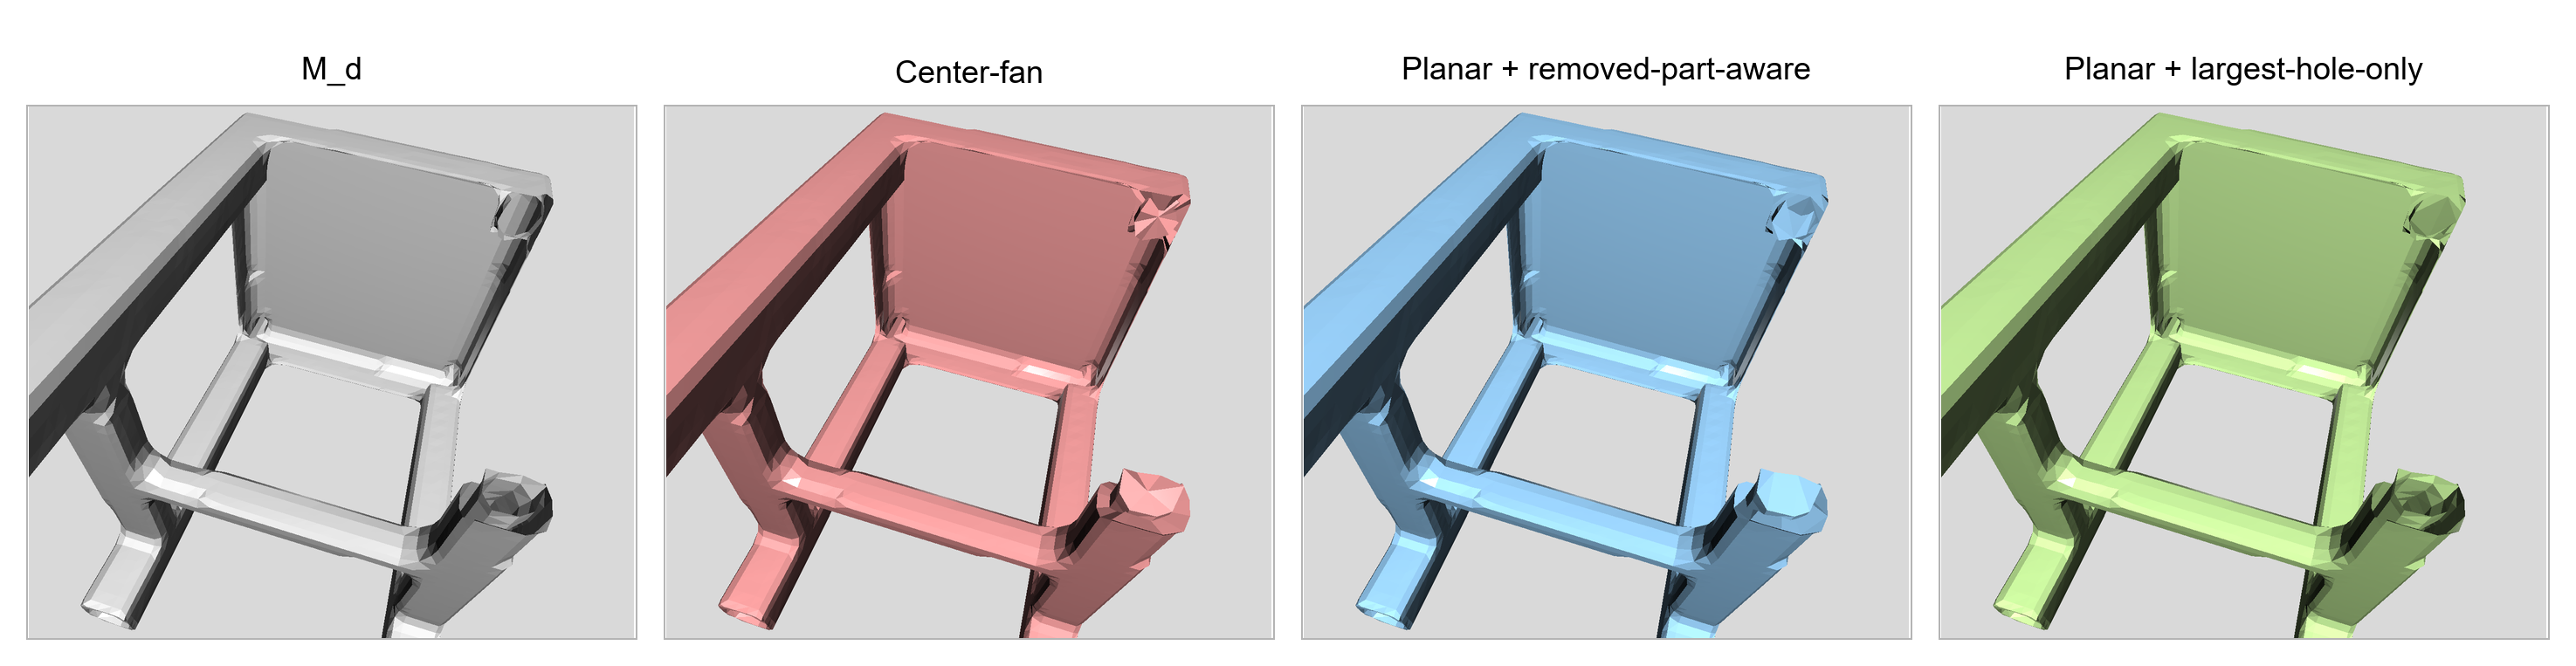

In [40]:
from PIL import Image
from IPython.display import display

display(Image.open("../results/vis/35580_compare.png"))